In [1]:
from pathlib import Path
import sys
import traceback
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import data_analysis.mea_analysis as mea
import data_analysis.loading_and_saving as las
import data_analysis.plotting as dap

In [2]:
BRW_BASE_FOLDER = Path("/media/ferdinand-forberger/RawDataBackUp")
MAIN_FOLDER = Path("/media/ferdinand-forberger/Seagate Portable Drive")
GRAPH_METRICS_PATH = MAIN_FOLDER / "graph_metrics.xlsx"



df_overview = mea.get_overview(MAIN_FOLDER)
df_overview = df_overview[df_overview["sles_saved"]==True]
df_overview.reset_index(inplace=True, drop=True)
df_overview["image_path"]= df_overview["folder_path"].astype(str) + "/org_image.png"
df_overview["mask_path"] = df_overview["folder_path"].astype(str) + "/mask.png"

#get metadata file to have info about which slice belongs to which group
df_metadata = pd.read_excel("/media/ferdinand-forberger/RawDataBackUp/meta_data_file.xlsx")
df_metadata["folder"] = df_metadata["animal_number"].astype(str) + "_" + df_metadata["slice_number"].astype(str)
df_overview = pd.merge(df_overview, df_metadata, left_on="folder", right_on="folder", how="left")
df_overview["sttc_path"] = df_overview["folder_path"] / "sttc.npy"

In [3]:
df_overview

,folder,folder_path,bin_path_x,analyzed,sle_path,sles_saved,image_path,mask_path,animal_number,slice_number,...,target_folder_base_path,start_time,end_time,kilosort_output_path,bin_path_y,brw_path,group,preincub,durations,sttc_path
0,8561_3,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8561,3,...,G:\8561_3,2025-04-18 21:16:58.937,2025-04-18 22:15:31.847,G:\8561_3\kilosort_output,G:\8561_3\bin.dat,E:\8561_3\Slice.brw,Tumor,Disinhib.-Solution,00:58:32.910000,/media/ferdinand-forberger/Seagate Portable Dr...
1,8561_5,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8561,5,...,G:\8561_5,2025-04-18 22:15:32.549,2025-04-19 07:07:25.082,G:\8561_5\kilosort_output,G:\8561_5\bin.dat,E:\8561_5\Slice.brw,Tumor,Disinhib.-Solution,08:51:52.533000,/media/ferdinand-forberger/Seagate Portable Dr...
2,8562_5,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8562,5,...,G:\8562_5,2025-04-21 10:03:03.732,2025-04-21 11:50:35.594,G:\8562_5\kilosort_output,G:\8562_5\bin.dat,E:\8562_5\Phase_00.brw,Sham,Disinhib.-Solution,01:47:31.862000,/media/ferdinand-forberger/Seagate Portable Dr...
3,8562_7,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8562,7,...,G:\8562_7,2025-04-21 11:50:36.300,2025-04-21 13:52:18.339,G:\8562_7\kilosort_output,G:\8562_7\bin.dat,E:\8562_7\Phase_02.brw,Sham,Disinhib.-Solution,02:01:42.039000,/media/ferdinand-forberger/Seagate Portable Dr...
4,8602_1,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8602,1,...,G:\8602_1,2025-04-19 07:07:25.734,2025-04-19 08:36:27.779,G:\8602_1\kilosort_output,G:\8602_1\bin.dat,E:\8602_1\R860-2_Normal_M1_Slice1_01.brw,Tumor,Disinhib.-Solution,01:29:02.045000,/media/ferdinand-forberger/Seagate Portable Dr...
5,8602_2,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8602,2,...,G:\8602_2,2025-04-19 08:36:28.623,2025-04-19 10:12:19.139,G:\8602_2\kilosort_output,G:\8602_2\bin.dat,E:\8602_2\R860-2_Normal_M1_Slice2_00.brw,Tumor,Disinhib.-Solution,01:35:50.516000,/media/ferdinand-forberger/Seagate Portable Dr...
6,8602_5,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8602,5,...,G:\8602_5,2025-04-19 10:12:20.035,2025-04-19 11:37:53.335,G:\8602_5\kilosort_output,G:\8602_5\bin.dat,E:\8602_5\R860-2_Normal_M1_Slice5_00.brw,Tumor,Disinhib.-Solution,01:25:33.300000,/media/ferdinand-forberger/Seagate Portable Dr...
7,8602_6,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seag

  0%|          | 0/22 [00:00<?, ?it/s]

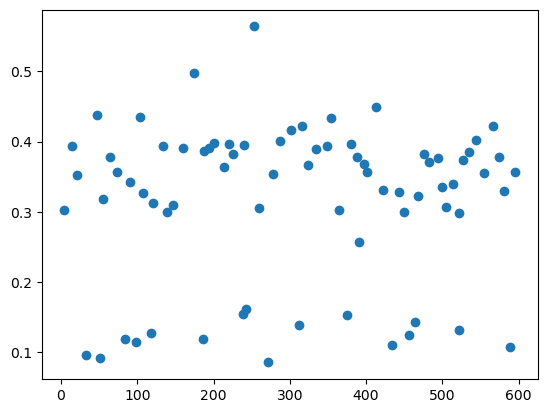

r_s=0.011, p=9.266e-01
r_p=0.048, p=6.811e-01


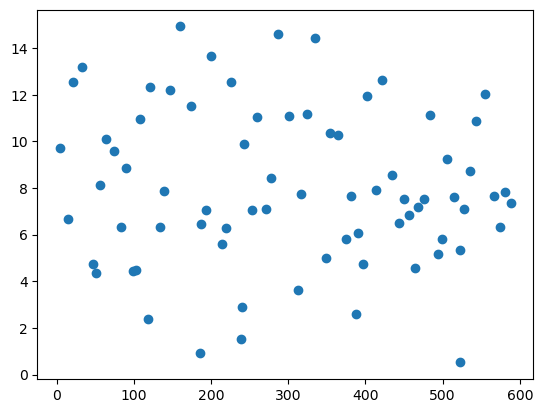

  5%|▍         | 1/22 [00:00<00:03,  5.57it/s]

r_s=-0.066, p=5.791e-01
r_p=-0.096, p=4.155e-01


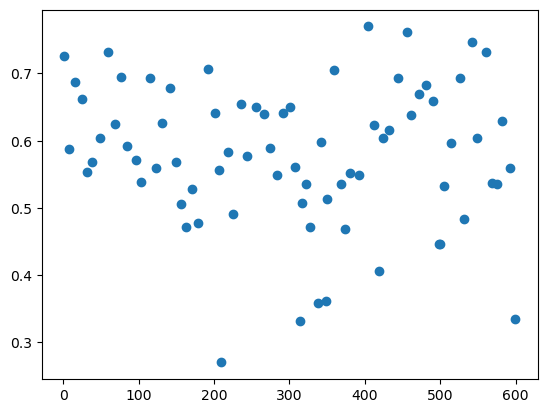

r_s=-0.099, p=3.964e-01
r_p=-0.096, p=4.123e-01


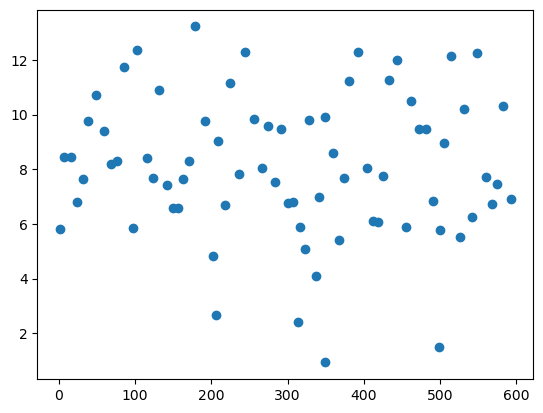

  9%|▉         | 2/22 [00:00<00:03,  6.33it/s]

r_s=-0.056, p=6.358e-01
r_p=-0.063, p=5.931e-01


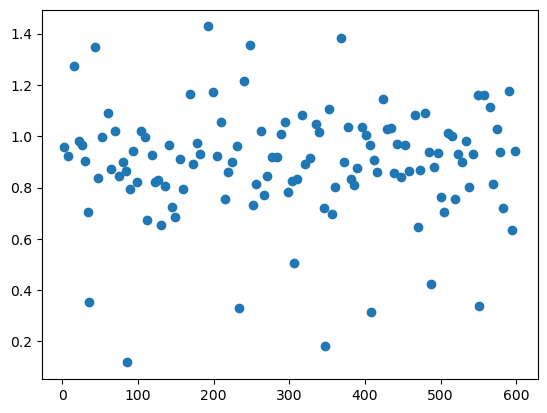

r_s=0.028, p=7.620e-01
r_p=0.002, p=9.795e-01


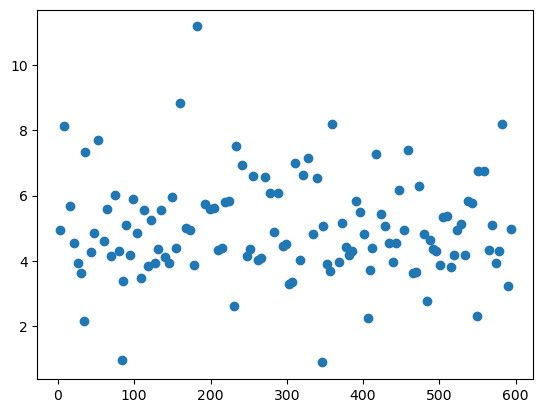

 14%|█▎        | 3/22 [00:00<00:02,  6.66it/s]

r_s=-0.026, p=7.761e-01
r_p=-0.043, p=6.434e-01


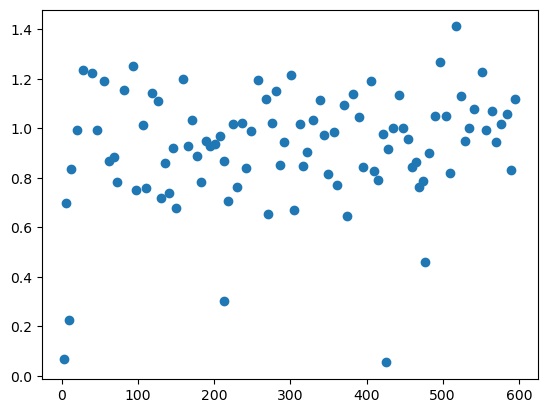

r_s=0.162, p=1.122e-01
r_p=0.177, p=8.220e-02


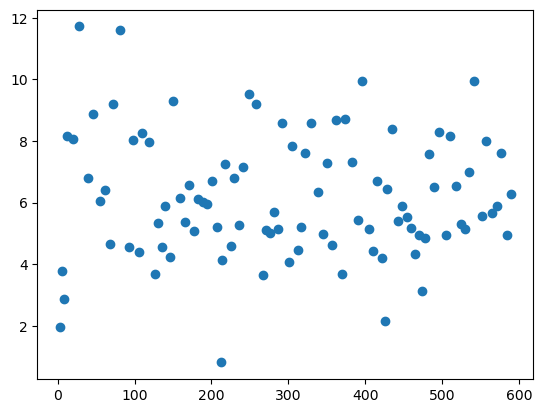

 18%|█▊        | 4/22 [00:00<00:02,  6.69it/s]

r_s=0.002, p=9.846e-01
r_p=-0.030, p=7.726e-01


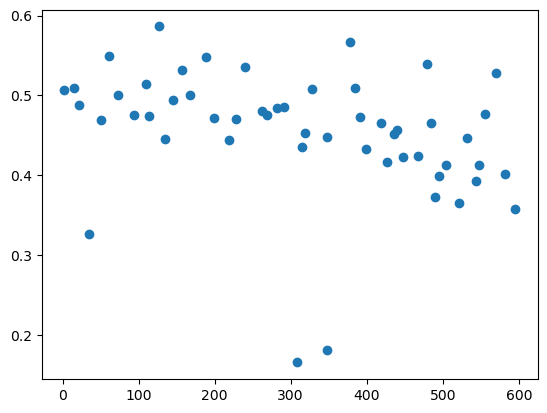

r_s=-0.479, p=2.894e-04
r_p=-0.315, p=2.180e-02


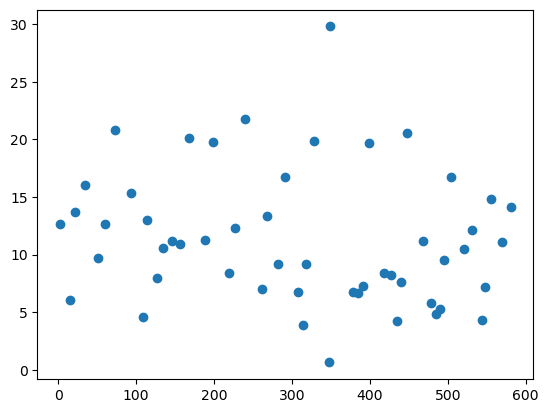

 23%|██▎       | 5/22 [00:00<00:02,  6.47it/s]

r_s=-0.204, p=1.473e-01
r_p=-0.173, p=2.203e-01


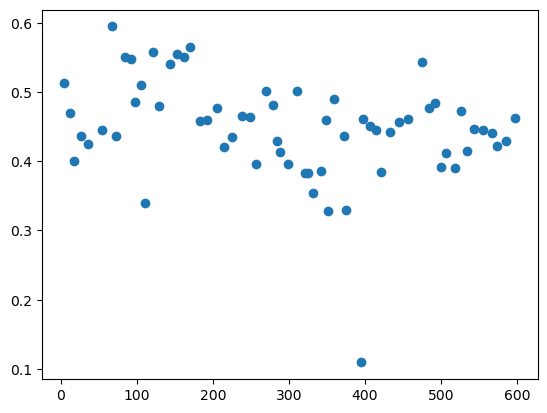

r_s=-0.312, p=1.198e-02
r_p=-0.297, p=1.705e-02


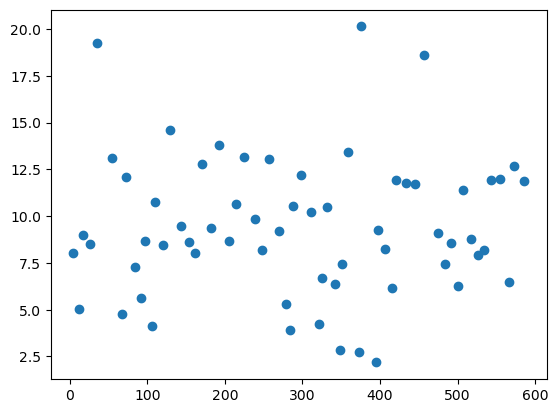

 27%|██▋       | 6/22 [00:01<00:03,  5.12it/s]

r_s=0.039, p=7.605e-01
r_p=0.030, p=8.173e-01


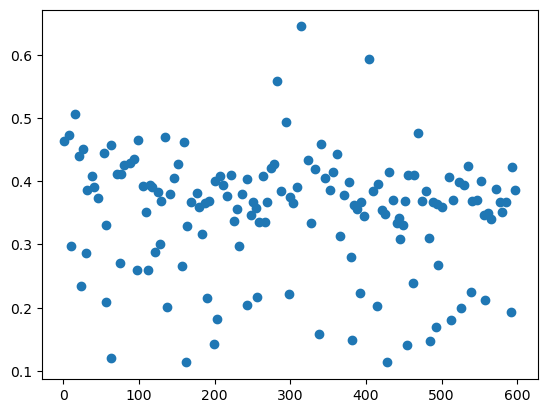

r_s=-0.165, p=4.420e-02
r_p=-0.118, p=1.510e-01


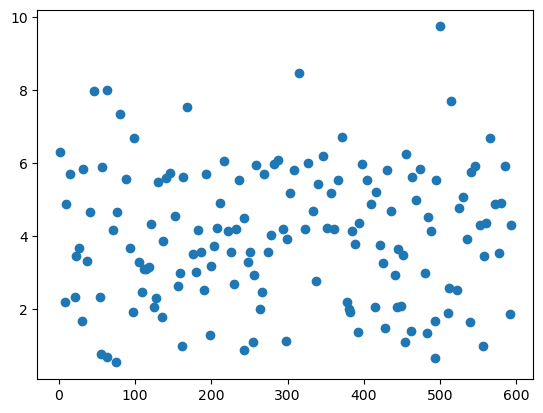

 32%|███▏      | 7/22 [00:01<00:02,  5.28it/s]

r_s=0.033, p=6.931e-01
r_p=0.020, p=8.045e-01


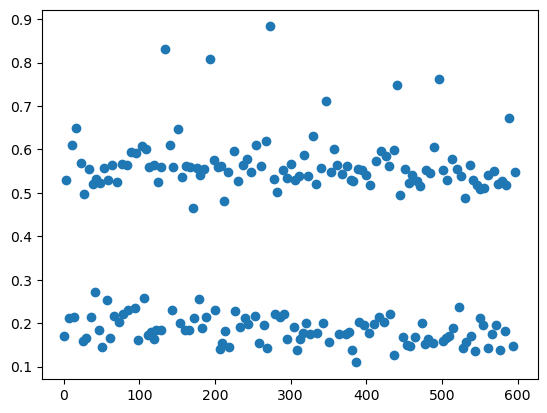

r_s=-0.124, p=7.823e-02
r_p=-0.034, p=6.333e-01


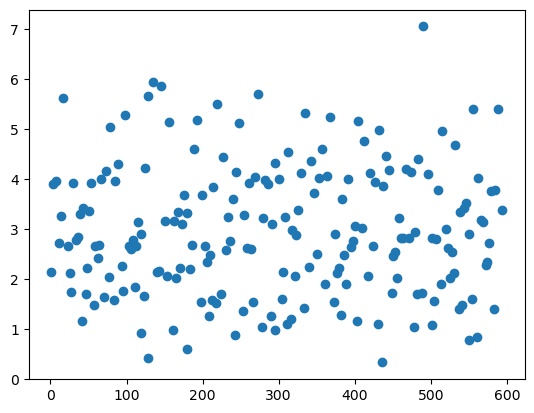

 36%|███▋      | 8/22 [00:01<00:02,  5.74it/s]

r_s=0.007, p=9.179e-01
r_p=-0.000, p=9.998e-01


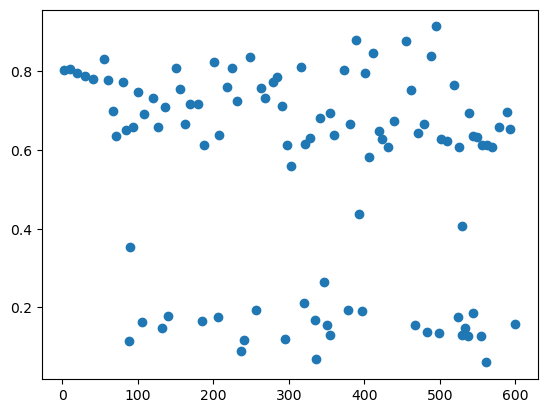

r_s=-0.297, p=2.279e-03
r_p=-0.215, p=2.907e-02


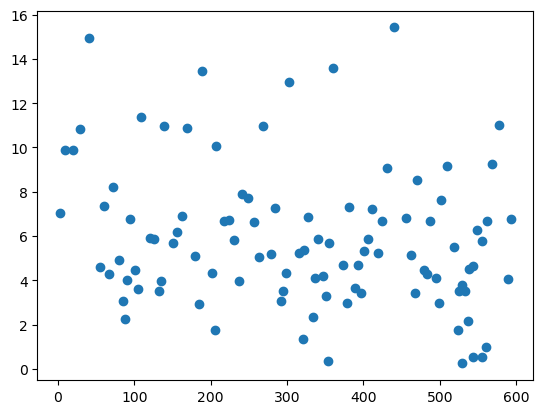

 41%|████      | 9/22 [00:01<00:02,  5.90it/s]

r_s=-0.206, p=3.731e-02
r_p=-0.236, p=1.706e-02


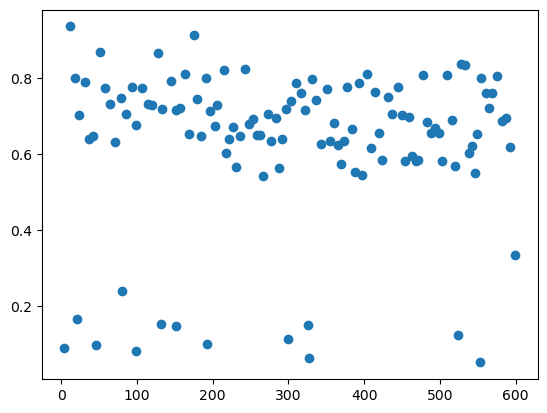

r_s=-0.090, p=3.310e-01
r_p=0.049, p=6.014e-01


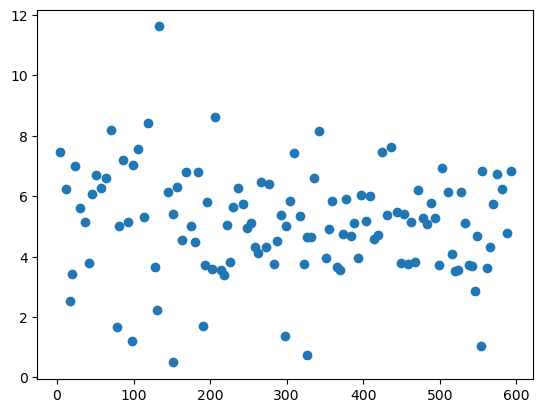

 45%|████▌     | 10/22 [00:01<00:01,  6.05it/s]

r_s=-0.110, p=2.362e-01
r_p=-0.100, p=2.833e-01


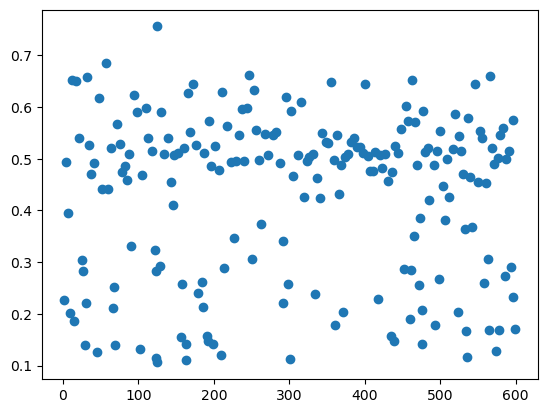

r_s=-0.002, p=9.777e-01
r_p=0.010, p=8.878e-01


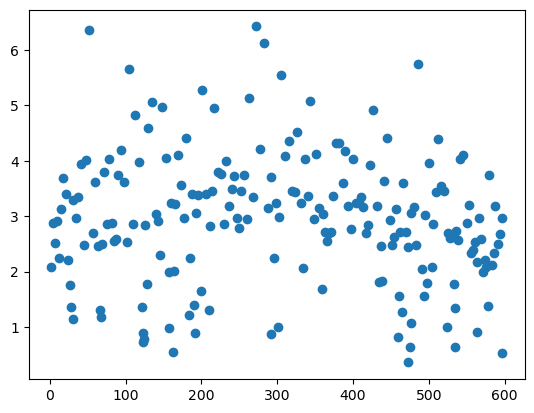

 50%|█████     | 11/22 [00:01<00:01,  5.97it/s]

r_s=-0.130, p=6.463e-02
r_p=-0.121, p=8.518e-02


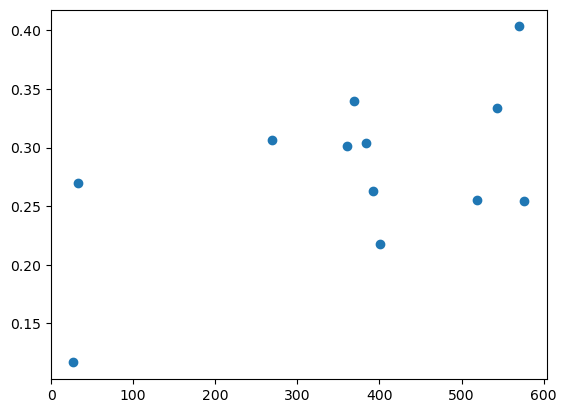

r_s=0.133, p=6.806e-01
r_p=0.550, p=6.391e-02


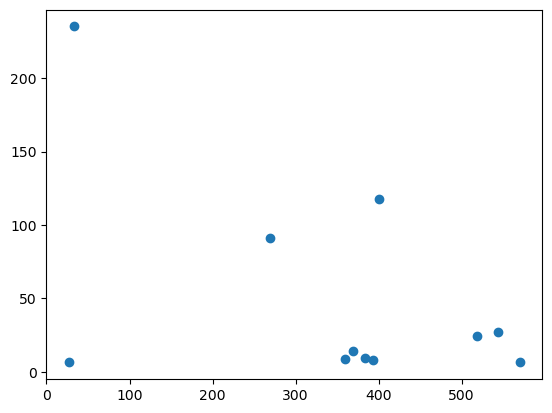

 55%|█████▍    | 12/22 [00:02<00:01,  6.07it/s]

r_s=-0.036, p=9.155e-01
r_p=-0.511, p=1.082e-01


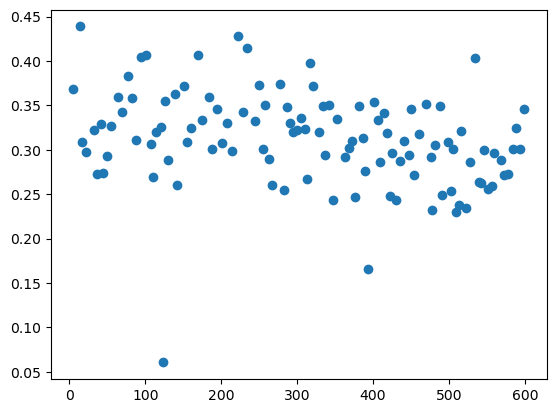

r_s=-0.377, p=3.842e-05
r_p=-0.297, p=1.402e-03


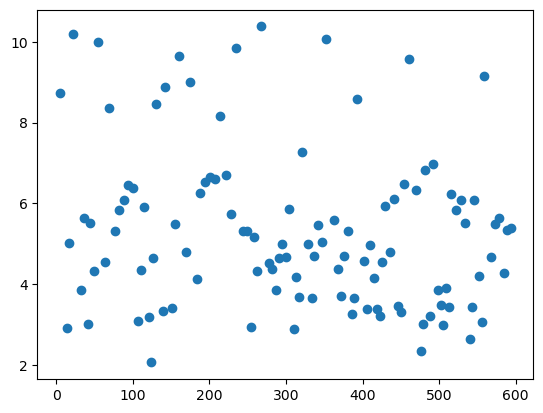

 59%|█████▉    | 13/22 [00:02<00:01,  5.91it/s]

r_s=-0.160, p=9.122e-02
r_p=-0.200, p=3.464e-02


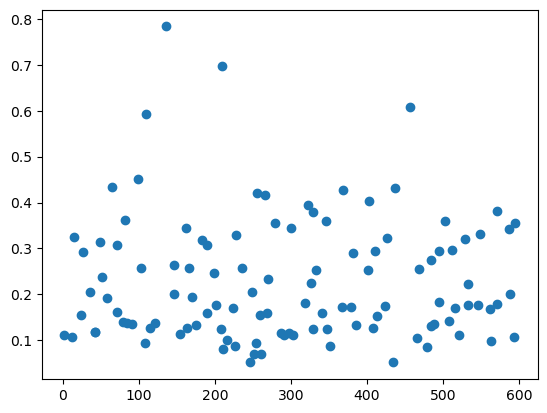

r_s=0.038, p=6.910e-01
r_p=-0.008, p=9.297e-01


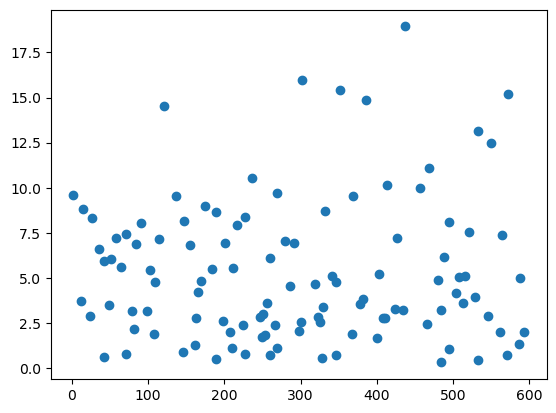

 64%|██████▎   | 14/22 [00:02<00:01,  5.94it/s]

r_s=-0.036, p=7.039e-01
r_p=0.027, p=7.793e-01


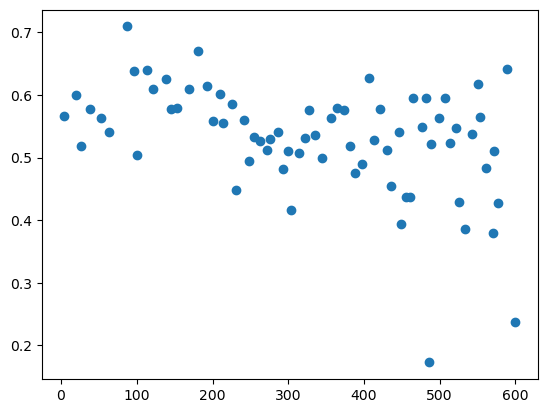

r_s=-0.398, p=5.363e-04
r_p=-0.433, p=1.446e-04


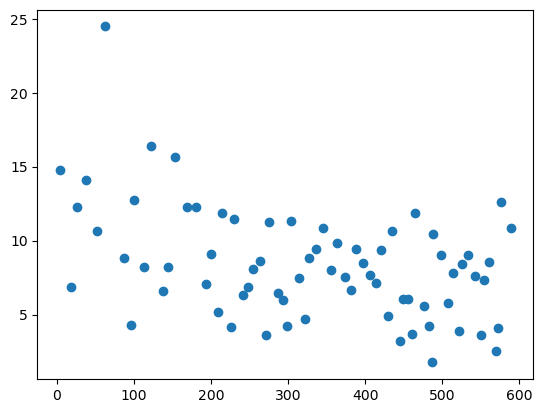

 68%|██████▊   | 15/22 [00:02<00:01,  5.86it/s]

r_s=-0.355, p=2.347e-03
r_p=-0.434, p=1.584e-04


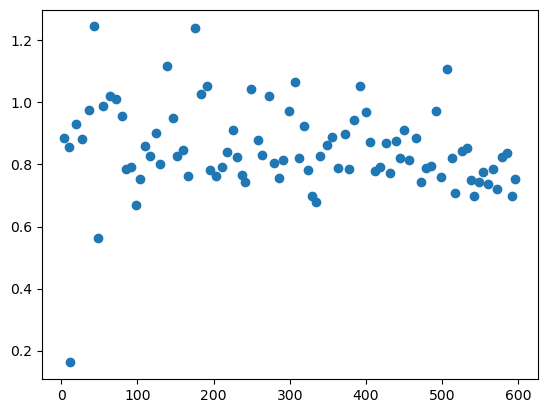

r_s=-0.297, p=4.463e-03
r_p=-0.158, p=1.377e-01


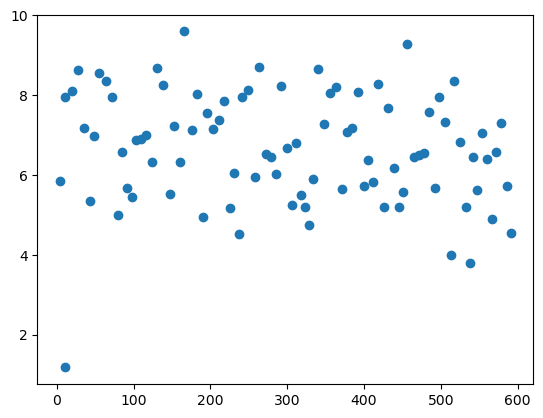

 73%|███████▎  | 16/22 [00:02<00:00,  6.02it/s]

r_s=-0.185, p=8.274e-02
r_p=-0.144, p=1.777e-01


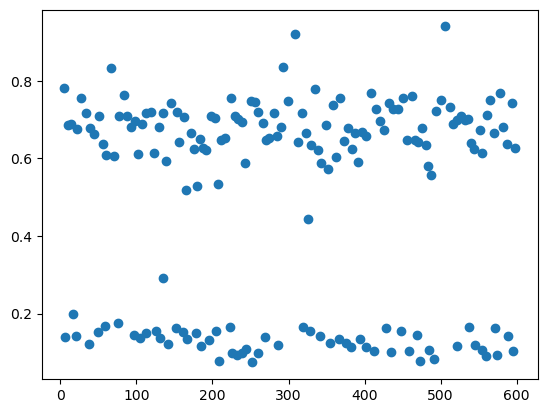

r_s=-0.022, p=7.741e-01
r_p=0.006, p=9.344e-01


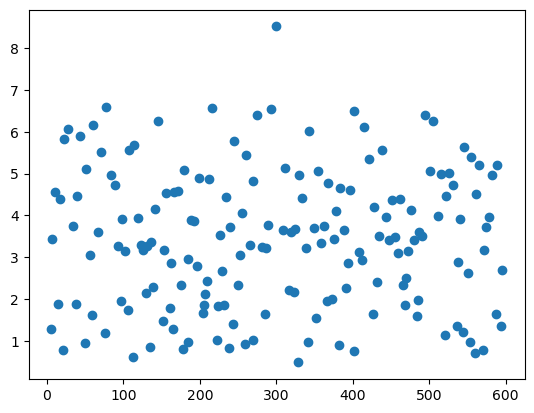

 77%|███████▋  | 17/22 [00:02<00:00,  6.30it/s]

r_s=0.019, p=8.055e-01
r_p=0.007, p=9.288e-01


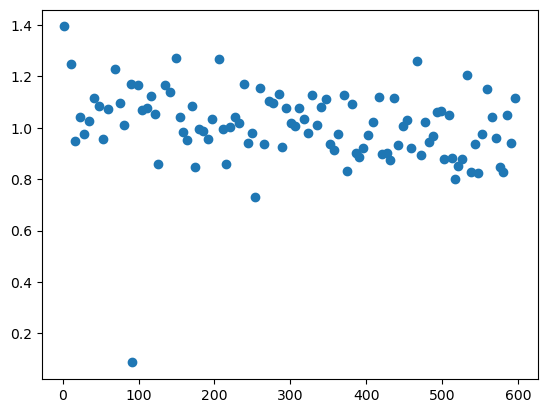

r_s=-0.337, p=4.310e-04
r_p=-0.214, p=2.813e-02


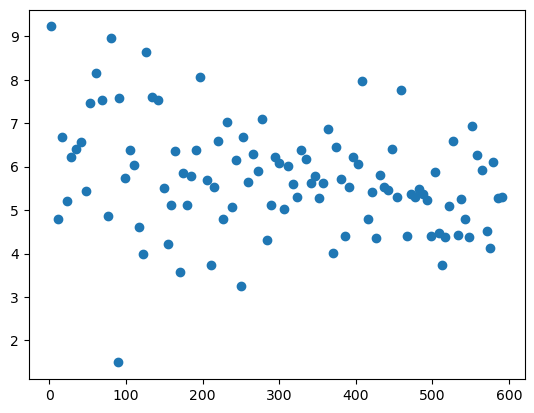

 82%|████████▏ | 18/22 [00:03<00:00,  6.10it/s]

r_s=-0.280, p=4.030e-03
r_p=-0.275, p=4.659e-03


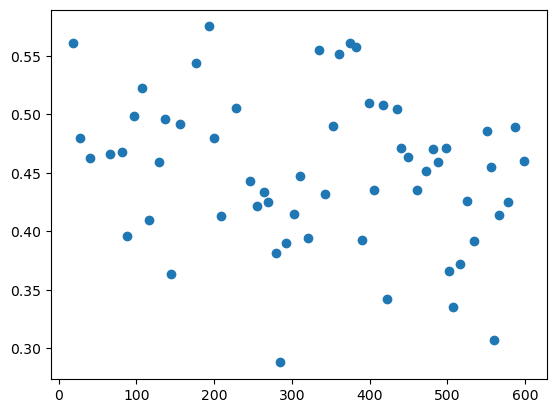

r_s=-0.231, p=7.801e-02
r_p=-0.235, p=7.259e-02


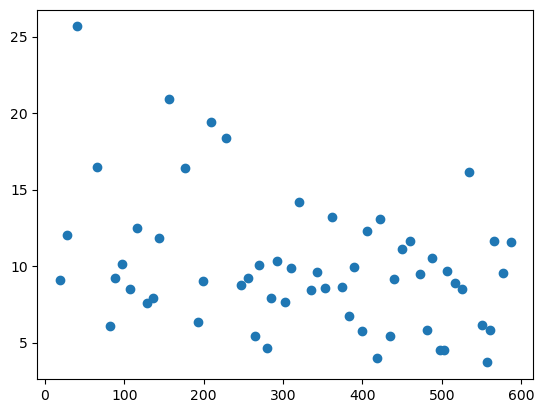

 86%|████████▋ | 19/22 [00:03<00:00,  6.14it/s]

r_s=-0.231, p=8.099e-02
r_p=-0.335, p=1.010e-02


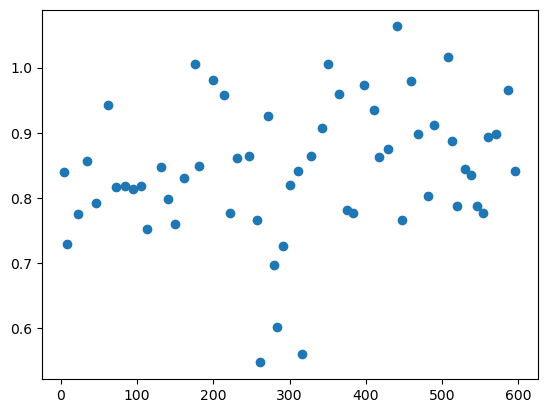

r_s=0.262, p=4.728e-02
r_p=0.223, p=9.286e-02


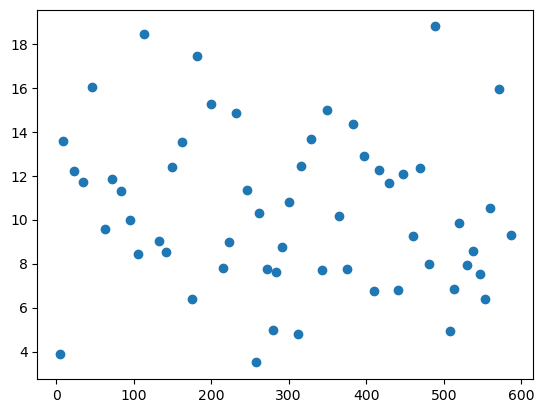

 91%|█████████ | 20/22 [00:03<00:00,  6.31it/s]

r_s=-0.168, p=2.116e-01
r_p=-0.149, p=2.679e-01


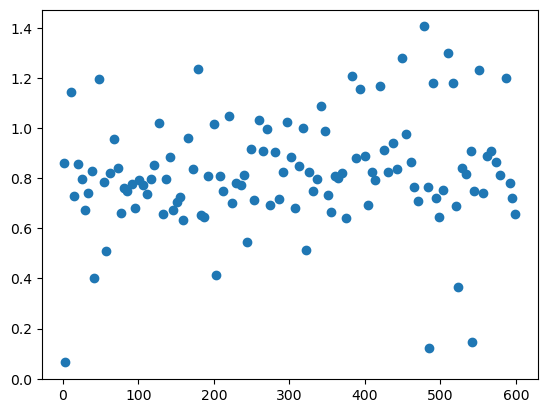

r_s=0.147, p=1.117e-01
r_p=0.144, p=1.194e-01


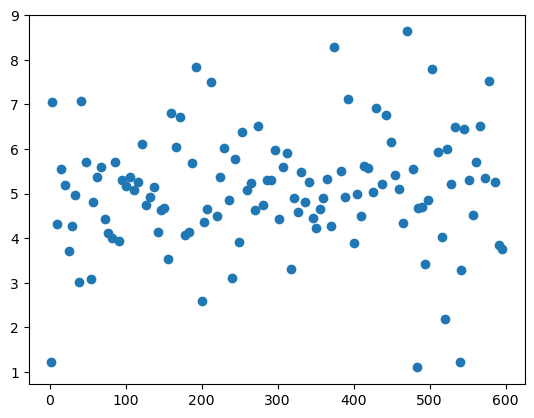

 95%|█████████▌| 21/22 [00:03<00:00,  6.03it/s]

r_s=0.093, p=3.149e-01
r_p=0.074, p=4.264e-01


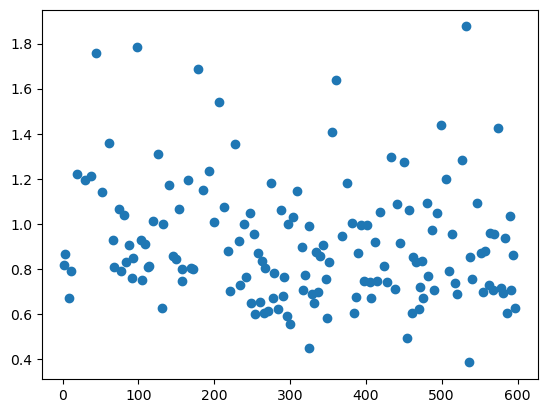

r_s=-0.174, p=3.232e-02
r_p=-0.163, p=4.416e-02


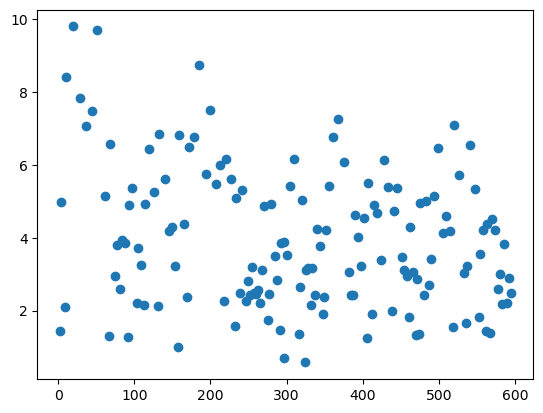

100%|██████████| 22/22 [00:03<00:00,  6.00it/s]

r_s=-0.181, p=2.613e-02
r_p=-0.248, p=2.175e-03


,spearman,spearman_p,pearson,pearson_p
0,0.010825,0.926557,0.048230,0.681137
1,-0.065531,0.579085,-0.096066,0.415526
2,-0.099346,0.396433,-0.096070,0.412267
3,-0.055964,0.635785,-0.063128,0.593112
4,0.027815,0.762008,0.002359,0.979511
5,-0.026231,0.776114,-0.042683,0.643447
6,0.162292,0.112236,0.177371,0.082199
7,0.001994,0.984617,-0.029876,0.772619
8,-0.478552,0.000289,-0.314540,0.021800
9,-0.203791,0.147313,-0.172912,0.220261


In [4]:
corrs = {"spearman": [], "spearman_p" : [], "pearson": [], "pearson_p": []}
SAMPLING_RATE = mea.SAMPLING_RATE
from scipy.stats import pearsonr, spearmanr
for i, row in tqdm(df_overview.iterrows(), total=len(df_overview)):
    NBs_path = row["sle_path"]
    NBs = np.load(NBs_path).T
    NB_dur_sec = (NBs[:,1] - NBs[:,0]) / SAMPLING_RATE
    plt.scatter(NBs[:,0]/SAMPLING_RATE, NB_dur_sec)
    plt.show()
    spear, spear_p = spearmanr(NBs[:,0]/SAMPLING_RATE, NB_dur_sec)
    pear, pear_p = pearsonr(NBs[:,0]/SAMPLING_RATE, NB_dur_sec)
    print(f"r_s={spear:.3f}, p={spear_p:.3e}")
    print(f"r_p={pear:.3f}, p={pear_p:.3e}")
    corrs["spearman"].append(spear)
    corrs["spearman_p"].append(spear_p)
    corrs["pearson"].append(pear)
    corrs["pearson_p"].append(pear_p)

    NB_distance = np.diff(NBs[:,0]) / SAMPLING_RATE
    plt.scatter(NBs[:-1,0]/SAMPLING_RATE, NB_distance)
    plt.show()
    spear, spear_p = spearmanr(NBs[:-1,0]/SAMPLING_RATE, NB_distance)
    pear, pear_p = pearsonr(NBs[:-1,0]/SAMPLING_RATE, NB_distance)
    print(f"r_s={spear:.3f}, p={spear_p:.3e}")
    print(f"r_p={pear:.3f}, p={pear_p:.3e}")
    corrs["spearman"].append(spear)
    corrs["spearman_p"].append(spear_p)
    corrs["pearson"].append(pear)
    corrs["pearson_p"].append(pear_p)

df_corrs = pd.DataFrame(corrs)
df_corrs
    

In [5]:
df_corrs.mean(axis=0), df_corrs.std(axis=0)

(spearman     -0.110539
 spearman_p    0.343974
 pearson      -0.099431
 pearson_p     0.348030
 dtype: float64,
 spearman      0.165350
 spearman_p    0.357086
 pearson       0.191440
 pearson_p     0.354122
 dtype: float64)

In [6]:
df_corrs_durs = df_corrs.iloc[::2].reset_index(drop=True)
df_corrs_distances = df_corrs.iloc[1::2].reset_index(drop=True)
df_corrs_durs["group"] = df_overview["group"]
df_corrs_distances["group"] = df_overview["group"]


In [15]:
df_corrs_durs.groupby("group").mean()

,spearman,spearman_p,pearson,pearson_p
group,,,,
Sham,-0.086113,0.192314,-0.065181,0.249109
Tumor,-0.147021,0.345024,-0.060268,0.369163


In [14]:
df_corrs_durs.groupby("group").std()

,spearman,spearman_p,pearson,pearson_p
group,,,,
Sham,0.232746,0.306330,0.210767,0.375442
Tumor,0.185269,0.381562,0.235458,0.362125


In [10]:
df_corrs_distances.groupby("group").mean()

,spearman,spearman_p,pearson,pearson_p
group,,,,
Sham,-0.131230,0.328893,-0.157705,0.323404
Tumor,-0.077169,0.481874,-0.118572,0.429854


In [11]:
df_corrs_distances.groupby("group").std()

,spearman,spearman_p,pearson,pearson_p
group,,,,
Sham,0.14558,0.379611,0.163343,0.351677
Tumor,0.08539,0.341051,0.153046,0.354003


In [17]:
np.sum(df_corrs_distances["spearman_p"] <0.05)

np.int64(4)